## Contents

1. [FFT Beamformer Fundamentals](#fft-beamformer-fundamentals)
2. [Angular Resolution and Spectral Leakage](#angular-resolution-and-spectral-leakage)

<a id="fft-beamformer-fundamentals"></a>

## FFT Beamformer Fundamentals

The FFT beamformer is a conventional delay-and-sum beamformer evaluated simultaneously over a uniformly spaced grid of spatial frequencies. For a uniform linear array (ULA), its beamforming weights form a discrete Fourier transform (DFT) basis. Therefore, all beam outputs can be computed efficiently using a single FFT across the antenna channels.

For an array with $N$ elements, the spatial snapshot at index $k$ is

$$
\mathbf{x}[k]
=
\begin{bmatrix}
x_0[k] &
x_1[k] &
\cdots &
x_{N-1}[k]
\end{bmatrix}^{T}.
$$

Here, $k$ denotes the snapshot index, while the elements of $\mathbf{x}[k]$ contain the complex samples measured across the array.

### Bank of spatial FIR filters

The FFT beamformer can be interpreted as a bank of spatial finite-impulse-response (FIR) filters. Each filter applies a different linear phase progression across the antenna channels and therefore steers the array toward a different spatial frequency.

<p align="center">
  <img
    src="../docs/images/fft_bank_of_fir.png"
    alt="FFT beamformer represented as a bank of spatial FIR filters"
    width="60%">
</p>

For an $M$-point spatial FFT, where typically $M \geq N$, the normalized weight vector of the $m$-th beam is

$$
\mathbf{w}_m
=
\frac{1}{\sqrt{N}}
\begin{bmatrix}
1 \\
e^{j2\pi m/M} \\
e^{j2\pi m2/M} \\
\vdots \\
e^{j2\pi m(N-1)/M}
\end{bmatrix},
\qquad
m=0,1,\ldots,M-1.
$$

The corresponding beamformer output is

$$
y_m[k]
=
\mathbf{w}_m^{H}\mathbf{x}[k]
=
\frac{1}{\sqrt{N}}
\sum_{n=0}^{N-1}
x_n[k]e^{-j2\pi mn/M}.
$$

Thus, the outputs of the complete filter bank are the $M$-point DFT of the spatial snapshot, with zero-padding applied when $M>N$.

After applying `fftshift`, the centered FFT-bin index is

$$
\tilde{m}
=
m-\frac{M}{2},
\qquad
\tilde{m}
=
-\frac{M}{2},\ldots,\frac{M}{2}-1,
$$

and its normalized spatial frequency is

$$
\nu_{\tilde{m}}
=
\frac{\tilde{m}}{M}.
$$

For a ULA with inter-element spacing $d$ and wavelength $\lambda$, spatial frequency and direction of arrival are related by

$$
\nu
=
\frac{d}{\lambda}\sin\theta.
$$

Therefore, the angle associated with the $\tilde{m}$-th FFT bin is

$$
\theta_{\tilde{m}}
=
\arcsin\left(
\frac{\lambda}{d}
\frac{\tilde{m}}{M}
\right).
$$

For half-wavelength spacing, $d=\lambda/2$, this becomes

$$
\theta_{\tilde{m}}
=
\arcsin\left(
\frac{2\tilde{m}}{M}
\right).
$$

### Spatial power spectrum

For a single snapshot, the spatial power in the $m$-th beam is

$$
P_m[k]
=
\left|y_m[k]\right|^2.
$$

For $L$ snapshots, a more stable spatial spectrum is obtained by noncoherently averaging the beam powers:

$$
\hat{P}_m
=
\frac{1}{L}
\sum_{k=0}^{L-1}
\left|y_m[k]\right|^2.
$$

Equivalently, using the sample covariance matrix

$$
\hat{\mathbf{R}}
=
\frac{1}{L}
\sum_{k=0}^{L-1}
\mathbf{x}[k]\mathbf{x}^{H}[k],
$$

the averaged FFT-beamformer spectrum can be written as

$$
\hat{P}_m
=
\mathbf{w}_m^{H}
\hat{\mathbf{R}}
\mathbf{w}_m.
$$

Peaks of $\hat{P}_m$ indicate the spatial-frequency bins, and therefore the directions, from which the strongest signals arrive. Increasing the FFT size $M$ produces a denser angular grid through zero-padding, but does not improve the physical angular resolution determined by the array aperture.

<a id="angular-resolution-and-spectral-leakage"></a>

## Angular Resolution and Spectral Leakage

The performance of the FFT beamformer is primarily determined by the physical aperture of the antenna array and by the correspondence between the target spatial frequencies and the discrete FFT bins.

Two important effects are considered below:

1. degradation of angular resolution away from broadside;
2. spectral leakage caused by mismatch between the target direction and the FFT grid.

### Angular resolution

For a uniform linear array with $N$ elements and inter-element spacing $d$, the phase progression produced by a signal arriving from angle $\theta$ is determined by the normalized spatial frequency

$$
\nu(\theta)
=
\frac{d}{\lambda}\sin\theta.
$$

For half-wavelength spacing, $d=\lambda/2$, this becomes

$$
\nu(\theta)
=
\frac{1}{2}\sin\theta.
$$

The FFT beamformer has approximately constant resolution in spatial frequency. For a uniformly weighted array, the first-null width in spatial frequency is approximately

$$
\Delta \nu_{\mathrm{FN}}
\approx
\frac{2}{N}.
$$

However, the FFT grid is not uniform in angle because the relationship between spatial frequency and angle is nonlinear. Differentiating the spatial-frequency mapping gives

$$
\frac{d\nu}{d\theta}
=
\frac{d}{\lambda}\cos\theta.
$$

Therefore, a fixed spatial-frequency interval corresponds approximately to the angular interval

$$
\Delta\theta
\approx
\frac{\lambda}{d\cos\theta_0}
\Delta\nu,
$$

where $\theta_0$ is the beam direction.

The angular first-null width can consequently be approximated as

$$
\Delta\theta_{\mathrm{FN}}
\approx
\frac{2\lambda}
{Nd\cos\theta_0}.
$$

Similarly, the approximate half-power beamwidth is

$$
\Delta\theta_{\mathrm{HPBW}}
\approx
0.886
\frac{\lambda}
{Nd\cos\theta_0}.
$$

Both expressions contain the factor $1/\cos\theta_0$. The angular main lobe is therefore narrowest near broadside and becomes wider as the beam approaches endfire.

As a result, two targets with a fixed angular separation may be resolved near broadside but merged when the same target pair is moved away from broadside.

The following example compares two equal-power, uncorrelated targets with the same angular separation. In the broadside case, two distinct peaks are visible. In the off-boresight case, the reduced separation in spatial frequency causes the two responses to merge.

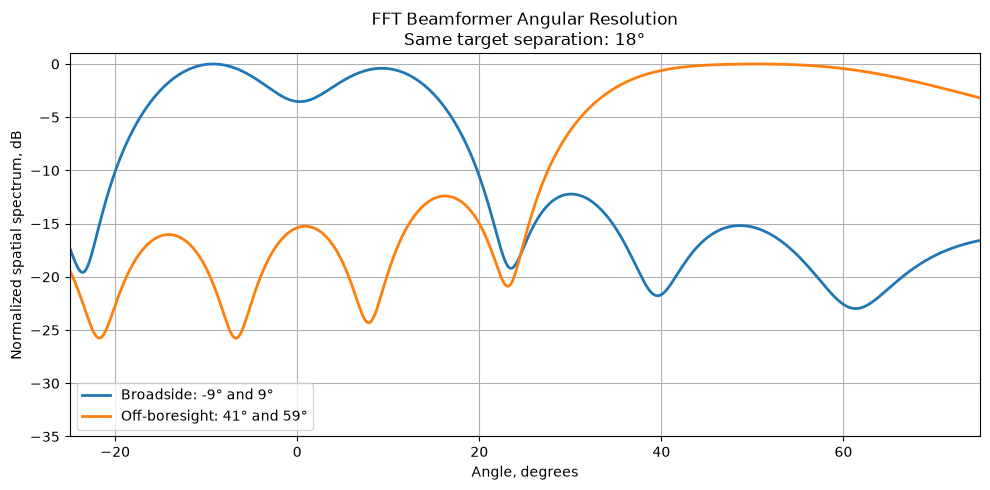

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
n_antennas = 8
n_fft = 4096
n_snapshots = 512
angle_separation_deg = 18.0
snr_db = 40.0

# Same angular separation in both cases
broadside_targets_deg = np.array([
    -angle_separation_deg / 2,
    +angle_separation_deg / 2,
])

off_boresight_center_deg = 50.0
off_boresight_targets_deg = np.array([
    off_boresight_center_deg - angle_separation_deg / 2,
    off_boresight_center_deg + angle_separation_deg / 2,
])

rng = np.random.default_rng(7)
antenna_index = np.arange(n_antennas)

# ------------------------------------------------------------
# Half-wavelength ULA steering vector
# ------------------------------------------------------------
def steering_vector(angle_deg):
    angle_rad = np.deg2rad(angle_deg)

    return np.exp(
        1j * np.pi * antenna_index * np.sin(angle_rad)
    )


# ------------------------------------------------------------
# Simulate uncorrelated targets and calculate FFT spectrum
# ------------------------------------------------------------
def fft_beamformer_spectrum(target_angles_deg):
    steering_matrix = np.column_stack([
        steering_vector(angle)
        for angle in target_angles_deg
    ])

    # Independent complex target amplitudes across snapshots
    target_signals = (
        rng.standard_normal(
            (len(target_angles_deg), n_snapshots)
        )
        + 1j
        * rng.standard_normal(
            (len(target_angles_deg), n_snapshots)
        )
    ) / np.sqrt(2.0)

    snapshots = steering_matrix @ target_signals

    signal_power = np.mean(np.abs(snapshots) ** 2)
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))

    noise = np.sqrt(noise_power / 2.0) * (
        rng.standard_normal(snapshots.shape)
        + 1j * rng.standard_normal(snapshots.shape)
    )

    snapshots += noise

    beam_output = np.fft.fftshift(
        np.fft.fft(
            snapshots,
            n=n_fft,
            axis=0,
        ),
        axes=0,
    )

    spectrum = np.mean(
        np.abs(beam_output) ** 2,
        axis=1,
    )

    spectrum /= np.max(spectrum)

    return 10.0 * np.log10(
        np.maximum(spectrum, 1e-8)
    )


# ------------------------------------------------------------
# FFT spatial-frequency and angular grids
# ------------------------------------------------------------
spatial_frequency = np.fft.fftshift(
    np.fft.fftfreq(n_fft)
)

valid = np.abs(2.0 * spatial_frequency) <= 1.0

angle_grid_deg = np.rad2deg(
    np.arcsin(
        2.0 * spatial_frequency[valid]
    )
)

broadside_spectrum_db = fft_beamformer_spectrum(
    broadside_targets_deg
)[valid]

off_boresight_spectrum_db = fft_beamformer_spectrum(
    off_boresight_targets_deg
)[valid]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    angle_grid_deg,
    broadside_spectrum_db,
    linewidth=2,
    label=(
        "Broadside: "
        f"{broadside_targets_deg[0]:.0f}° and "
        f"{broadside_targets_deg[1]:.0f}°"
    ),
)

plt.plot(
    angle_grid_deg,
    off_boresight_spectrum_db,
    linewidth=2,
    label=(
        "Off-boresight: "
        f"{off_boresight_targets_deg[0]:.0f}° and "
        f"{off_boresight_targets_deg[1]:.0f}°"
    ),
)

plt.xlabel("Angle, degrees")
plt.ylabel("Normalized spatial spectrum, dB")
plt.title(
    "FFT Beamformer Angular Resolution\n"
    f"Same target separation: {angle_separation_deg:.0f}°"
)
plt.xlim(-25, 75)
plt.ylim(-35, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

This example uses an $18^\circ$ separation. With an eight-element ULA, the broadside pair produces two visible maxima, while the pair centered at $50^\circ$ produces an approximately merged response.

The same behavior is evaluated with measured AWR2243 data using two corner-reflector scenarios.

<p align="center">
  <img
    src="../docs/images/fft_broadside_off_boresight.png"
    alt="FFT beamformer angular separation"
    width="90%">
</p>


In the broadside scenario, the reflectors are positioned symmetrically around the radar boresight with a lateral separation of $2.0$ m. In the off-boresight scenario, the reflector pair is shifted away from boresight while keeping the same $2.0$ m lateral separation and approximately the same range. The measured spectra therefore isolate the effect of steering angle on FFT-beamformer resolution.

### DoA mismatch and spectral leakage

The $m$-th FFT bin represents the spatial frequency

$$
\nu_m
=
\frac{\tilde{m}}{M},
$$

where $\tilde{m}$ is the centered FFT-bin index and $M$ is the FFT length.

For half-wavelength antenna spacing, the corresponding angular grid is

$$
\theta_m
=
\arcsin\left(
2\frac{\tilde{m}}{M}
\right).
$$

When a target spatial frequency exactly coincides with an FFT bin,

$$
\nu_t
=
\nu_m,
$$

the sampled spatial sinusoid is orthogonal to the other DFT basis vectors. In the ideal noise-free case, its FFT response is concentrated in one bin.

When the target is located between two FFT bins,

$$
\nu_t
=
\frac{m+\delta}{M},
\qquad
0 < |\delta| < 1,
$$

the target does not match any individual DFT basis vector. Its energy is distributed over several neighboring bins.

For one target, the FFT response has the form

$$
Y[m]
=
\sum_{n=0}^{N-1}
e^{j2\pi n(\nu_t-\nu_m)}.
$$

Evaluating the geometric series gives

$$
Y[m]
=
e^{j\pi(N-1)(\nu_t-\nu_m)}
\frac{
\sin\left(
\pi N(\nu_t-\nu_m)
\right)
}{
\sin\left(
\pi(\nu_t-\nu_m)
\right)
}.
$$

The corresponding power response is

$$
P[m]
=
\left|
\frac{
\sin\left(
\pi N(\nu_t-\nu_m)
\right)
}{
\sin\left(
\pi(\nu_t-\nu_m)
\right)
}
\right|^2.
$$

This Dirichlet-kernel response explains the spectral leakage observed for off-grid targets. The largest leakage occurs when the target lies approximately halfway between two FFT bins.

Zero-padding produces a finer sampled representation of this response and improves peak interpolation, but it does not eliminate leakage or improve the physical resolution of the array.

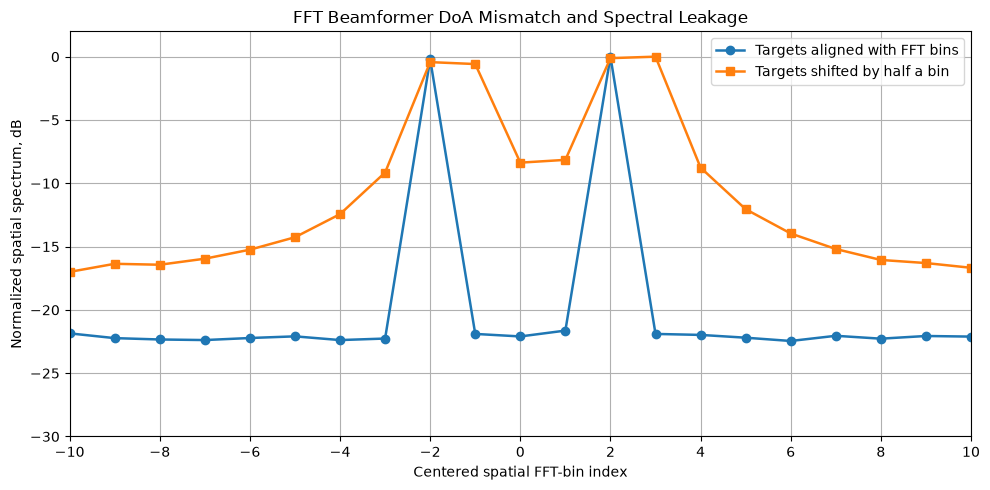

Bin-aligned target angles: [-7.181  7.181]
Half-bin-shifted target angles: [-5.379  8.989]
Aligned angular separation: 14.362 degrees
Mismatched angular separation: 14.369 degrees


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
n_antennas = 32
n_snapshots = 512
snr_db = 10.0

# Centered FFT-bin positions of two targets
target_bins = np.array([-2.0, 2.0])

# Exact bin alignment and half-bin mismatch
aligned_bins = target_bins
mismatched_bins = target_bins + 0.5

rng = np.random.default_rng(12)
antenna_index = np.arange(n_antennas)

# ------------------------------------------------------------
# Spatial frequency and angle
# ------------------------------------------------------------
def bin_to_spatial_frequency(bin_position):
    return bin_position / n_antennas


def spatial_frequency_to_angle(spatial_frequency):
    return np.rad2deg(
        np.arcsin(2.0 * spatial_frequency)
    )


aligned_spatial_frequencies = bin_to_spatial_frequency(
    aligned_bins
)

mismatched_spatial_frequencies = bin_to_spatial_frequency(
    mismatched_bins
)

aligned_angles_deg = spatial_frequency_to_angle(
    aligned_spatial_frequencies
)

mismatched_angles_deg = spatial_frequency_to_angle(
    mismatched_spatial_frequencies
)

# ------------------------------------------------------------
# Generate spatial snapshots
# ------------------------------------------------------------
def generate_snapshots(target_spatial_frequencies):
    steering_matrix = np.column_stack([
        np.exp(
            1j
            * 2.0
            * np.pi
            * antenna_index
            * spatial_frequency
        )
        for spatial_frequency in target_spatial_frequencies
    ])

    target_signals = (
        rng.standard_normal(
            (
                len(target_spatial_frequencies),
                n_snapshots,
            )
        )
        + 1j
        * rng.standard_normal(
            (
                len(target_spatial_frequencies),
                n_snapshots,
            )
        )
    ) / np.sqrt(2.0)

    snapshots = steering_matrix @ target_signals

    signal_power = np.mean(np.abs(snapshots) ** 2)
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))

    noise = np.sqrt(noise_power / 2.0) * (
        rng.standard_normal(snapshots.shape)
        + 1j * rng.standard_normal(snapshots.shape)
    )

    return snapshots + noise


# ------------------------------------------------------------
# N-point spatial FFT
# ------------------------------------------------------------
def fft_bin_spectrum(target_spatial_frequencies):
    snapshots = generate_snapshots(
        target_spatial_frequencies
    )

    beam_output = np.fft.fftshift(
        np.fft.fft(
            snapshots,
            n=n_antennas,
            axis=0,
        ),
        axes=0,
    )

    spectrum = np.mean(
        np.abs(beam_output) ** 2,
        axis=1,
    )

    spectrum /= np.max(spectrum)

    return 10.0 * np.log10(
        np.maximum(spectrum, 1e-8)
    )


aligned_spectrum_db = fft_bin_spectrum(
    aligned_spatial_frequencies
)

mismatched_spectrum_db = fft_bin_spectrum(
    mismatched_spatial_frequencies
)

fft_bins = np.arange(
    -n_antennas // 2,
    n_antennas // 2,
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    fft_bins,
    aligned_spectrum_db,
    marker="o",
    linewidth=1.8,
    label="Targets aligned with FFT bins",
)

plt.plot(
    fft_bins,
    mismatched_spectrum_db,
    marker="s",
    linewidth=1.8,
    label="Targets shifted by half a bin",
)

plt.xlabel("Centered spatial FFT-bin index")
plt.ylabel("Normalized spatial spectrum, dB")
plt.title("FFT Beamformer DoA Mismatch and Spectral Leakage")
plt.xlim(-10, 10)
plt.ylim(-30, 2)
plt.xticks(np.arange(-10, 11, 2))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Bin-aligned target angles:",
    np.round(aligned_angles_deg, 3),
)

print(
    "Half-bin-shifted target angles:",
    np.round(mismatched_angles_deg, 3),
)

print(
    "Aligned angular separation:",
    f"{np.diff(aligned_angles_deg)[0]:.3f} degrees",
)

print(
    "Mismatched angular separation:",
    f"{np.diff(mismatched_angles_deg)[0]:.3f} degrees",
)

When the target directions coincide with FFT bins, their energy is concentrated in narrow peaks. A half-bin DoA mismatch spreads the energy across neighboring bins, broadening the peaks and increasing spectral leakage. This reduces peak sharpness and can make closely spaced targets more difficult to distinguish.

The DoA estimate can be refined beyond the discrete FFT grid using peak-interpolation techniques, such as parabolic interpolation, quadratic interpolation in the logarithmic spectrum, or phase-based estimators. Zero-padding provides a denser angular grid and supports more accurate interpolation, while more advanced methods such as Quinn’s estimator or Jacobsen’s estimator can further reduce the off-grid frequency-estimation error.